In [3]:
import pandas as pd

# 1️⃣ Load dataset
df = pd.read_excel("ALL_with_features.xlsx")

# 2️⃣ Clean column names
df.columns = df.columns.str.strip()              # remove leading/trailing spaces
df.columns = df.columns.str.replace(" ", "_")   # replace spaces with underscores

# 3️⃣ Fill missing DoK_Level values with median
df['DoK_Level'] = df['DoK_Level'].fillna(df['DoK_Level'].median())

# 4️⃣ Ensure numeric columns are correct type
numeric_cols = ['Lexical_Diversity', 'Avg_Sentence_Length', 'Readability', 'DoK_Level']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 5️⃣ Save changes permanently by overwriting the same file
df.to_excel("ALL_with_features.xlsx", index=False)

print("Dataset cleaned and saved permanently in the same file.")
print(df.head())

Dataset cleaned and saved permanently in the same file.
     Item_ID                                               Item  \
0  HiBloom_1  Anne had a password in her phone represented b...   
1  HiBloom_2  Musoke had two wives one in Kanginima village ...   
2  HiBloom_3  On the last Sunday of the holiday Your uncle d...   
3  HiBloom_4  During their baking lesson, the students were ...   
4  HiBloom_5  A certain member of your family re-wrote each ...   

               Construct Bloom_Level  \
0                Numbers    Analyse    
1   Data and Probability    Evaluate   
2                Numbers      Create   
3   Patterns and Algebra    Analyse    
4  Geometry and Measures    Evaluate   

                                  Bloom_Action_Verbs  DoK_Level  \
0  Analyze, Appraise, Break down, Categorize, Cla...          3   
1  Appraise; Argue; Assess; Check; Conclude; Conf...          3   
2  Adapt; Assemble; Combine; Compile; Compose; Co...          4   
3  Analyze, Appraise, Break down

C:\Users\nanyu\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


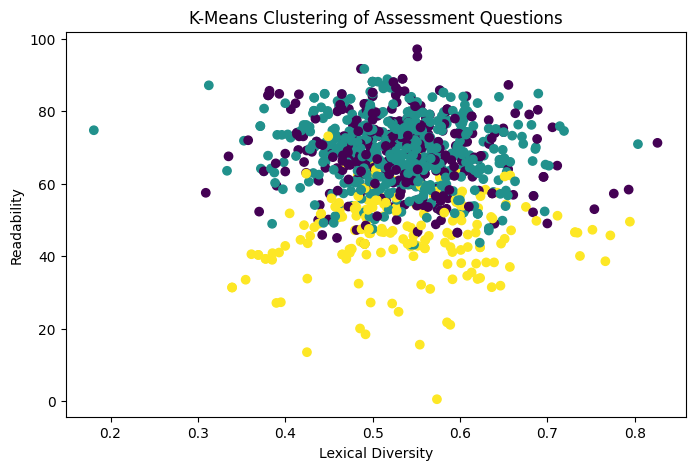


Topic 0:
['used', 'land', 'people', 'determine', 'use', 'task', 'time', 'number', 'school', 'students']

Topic 1:
['determine', 'task', 'shs', 'type', 'total', 'number', 'cost', 'school', 'ugx', '000']

Topic 2:
['income', '10', 'task', 'bags', 'determine', 'number', 'total', 'shs', 'ugx', '000']
                                                Item  Cluster  Topic
0  Anne had a password in her phone represented b...        1      1
1  Musoke had two wives one in Kanginima village ...        1      0
2  On the last Sunday of the holiday Your uncle d...        0      1
3  During their baking lesson, the students were ...        2      2
4  A certain member of your family re-wrote each ...        1      0
   Cluster  Topic
0        1      1
1        1      0
2        0      1
3        2      2
4        1      0
✅ Dataset updated with Cluster and Topic columns and saved.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1️⃣ Load cleaned dataset
df = pd.read_excel("ALL_with_features.xlsx")

# 2️⃣ Prepare numeric features for K-Means
features = df[['Lexical_Diversity','Avg_Sentence_Length','Readability','DoK_Level']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 3️⃣ Train K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(8,5))
plt.scatter(df['Lexical_Diversity'], df['Readability'], c=df['Cluster'], cmap='viridis')
plt.title("K-Means Clustering of Assessment Questions")
plt.xlabel("Lexical Diversity")
plt.ylabel("Readability")
plt.show()

# 4️⃣ Prepare text data for LDA
vectorizer = CountVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(df['Item'])

# 5️⃣ Train LDA model
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X_text)

# 6️⃣ Show top words per topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic {topic_idx}:")
    print([words[i] for i in topic.argsort()[-10:]])

# 7️⃣ Assign topic to each question
topic_results = lda.transform(X_text)
df['Topic'] = topic_results.argmax(axis=1)

# 8️⃣ View results
print(df[['Item','Cluster','Topic']].head()) 
import pandas as pd

# Assuming df is the DataFrame you trained and it already has Cluster and Topic
print(df[['Cluster', 'Topic']].head())  # confirm they exist in memory

# Save changes permanently to the same file
df.to_excel("ALL_with_features.xlsx", index=False)
print("✅ Dataset updated with Cluster and Topic columns and saved.")

In [5]:
import joblib

# Save K-Means model
joblib.dump(kmeans, "kmeans_model.pkl")

# Save LDA model
joblib.dump(lda, "lda_model.pkl")

print("K-Means and LDA models saved as .pkl files")

K-Means and LDA models saved as .pkl files


In [12]:
%pip install dataframe-image

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.7 MB 493.7 kB/s eta 0:00:13
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ------ --------------------------------- 1.0/6.7 MB 508.4 kB/s eta 0:00:12
   ------ --------------------------------- 1.0/6.7 MB 508.4 kB/s eta 0:00:12
   ------ --------------------------------- 1.

In [14]:
import pandas as pd
import dataframe_image as dfi  # pip install dataframe-image

# --- Prepare topic data ---
topics = {
    0: ['used', 'land', 'people', 'determine', 'use', 'task', 'time', 'number', 'school', 'students'],
    1: ['determine', 'task', 'shs', 'type', 'total', 'number', 'cost', 'school', 'ugx', '000'],
    2: ['income', '10', 'task', 'bags', 'determine', 'number', 'total', 'shs', 'ugx', '000']
}

example_questions = {
    0: "Musoke had two wives one in Kanginima village …",
    1: "Anne had a password in her phone …",
    2: "During their baking lesson …"
}

# --- Create DataFrame ---
topic_df = pd.DataFrame({
    "Topic": list(topics.keys()),
    "Top Words": [", ".join(words) for words in topics.values()],
    "Example Question": [example_questions[i] for i in topics.keys()]
})

# --- Export as high-quality image using Matplotlib ---
dfi.export(topic_df, "lda_topics_table.png", table_conversion="matplotlib")
print("✅ LDA topic table image saved as 'lda_topics_table.png'")

✅ LDA topic table image saved as 'lda_topics_table.png'


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import pickle

#  Load your original dataset
df = pd.read_excel("ALL_with_features.xlsx")  # or CSV if that's what you used

#  Recreate vectorizer
vectorizer = CountVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(df['Item'])

#  Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
print("✅ Vectorizer saved")

✅ Vectorizer saved
